### Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits, fetch_olivetti_faces
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import time
from torchsummary import summary

seed_value = 12345

# Autoencoder

### Loading digits dataset from Scikit-learn

In [ ]:
digits = load_digits()
X = digits.images / 16.0
y = digits.target

print("Shape of dataset images:", X.shape)
print("Shape of dataset labels:", y.shape)

print("Minimum pixel value of dataset images:", np.min(X))
print("Maximum pixel value of dataset images:", np.max(X))
print("Minimum label value of dataset images:", np.min(y))
print("Maximum label value of dataset images:", np.max(y))

Shape of dataset images: (1797, 8, 8)
Shape of dataset labels: (1797,)
Minimum pixel value of dataset images: 0.0
Maximum pixel value of dataset images: 1.0
Minimum label value of dataset images: 0
Maximum label value of dataset images: 9


### Visualization of some samples from the dataset

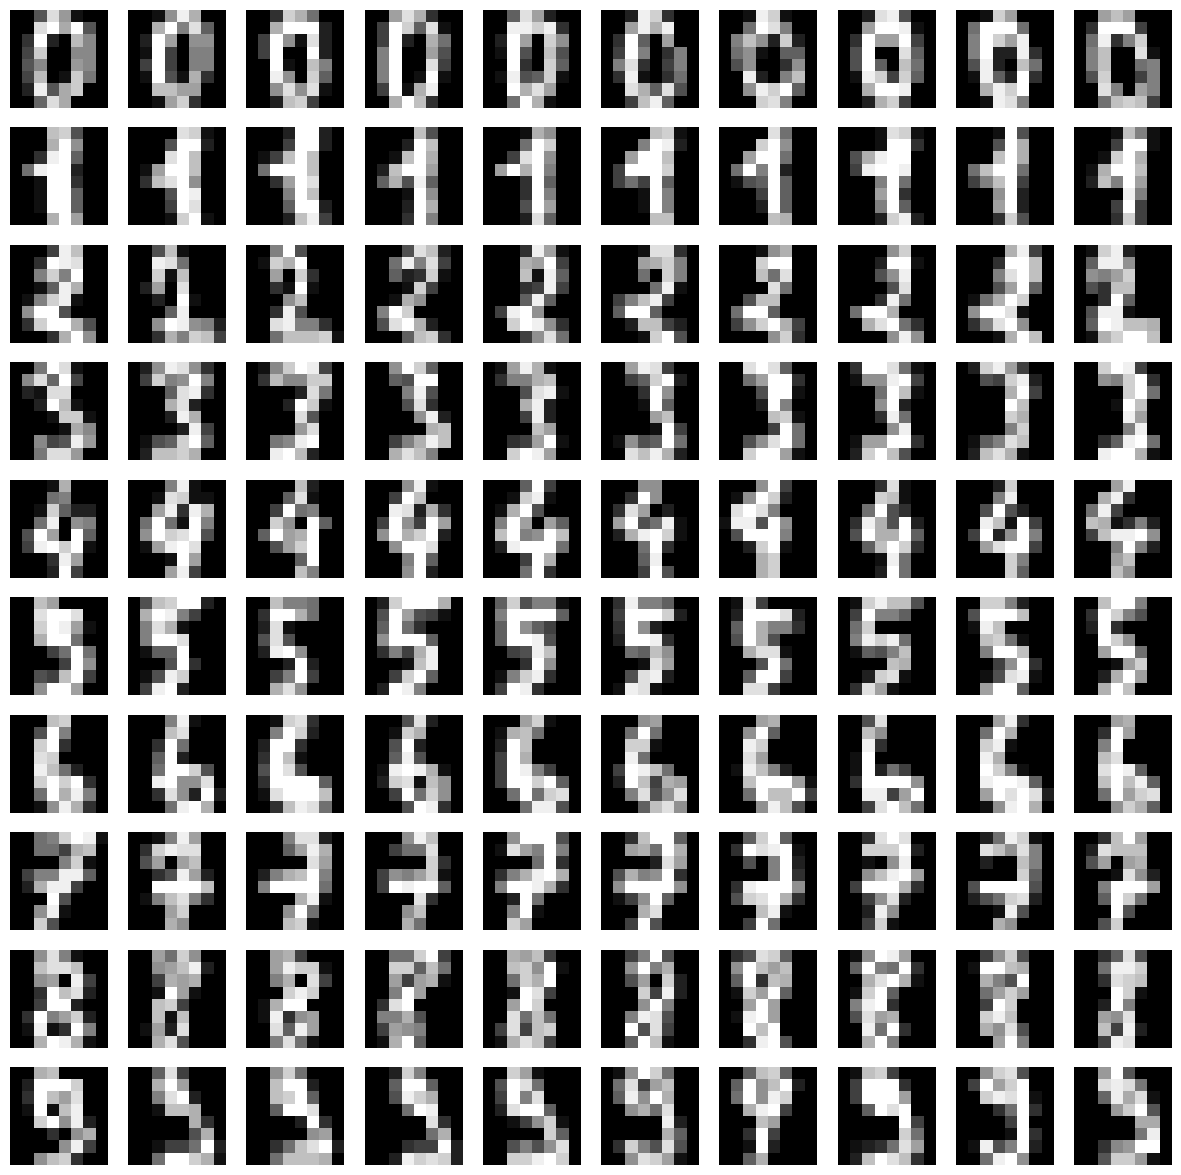

In [ ]:
fig, ax = plt.subplots(10, 10, figsize=(15, 15))

for digit_idx in range(10):
  occurance_idx_array = np.where(y == digit_idx)

  for j in range(10):
    ax[digit_idx, j].imshow(X[occurance_idx_array[0][j]], cmap='gray')
    ax[digit_idx, j].axis('off')

plt.show()

### Dividing the dataset into train, validation and test sets

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=seed_value*1)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=seed_value*2)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(1257, 8, 8)
(270, 8, 8)
(270, 8, 8)
(1257,)
(270,)
(270,)


### Creating a noisy version of the dataset

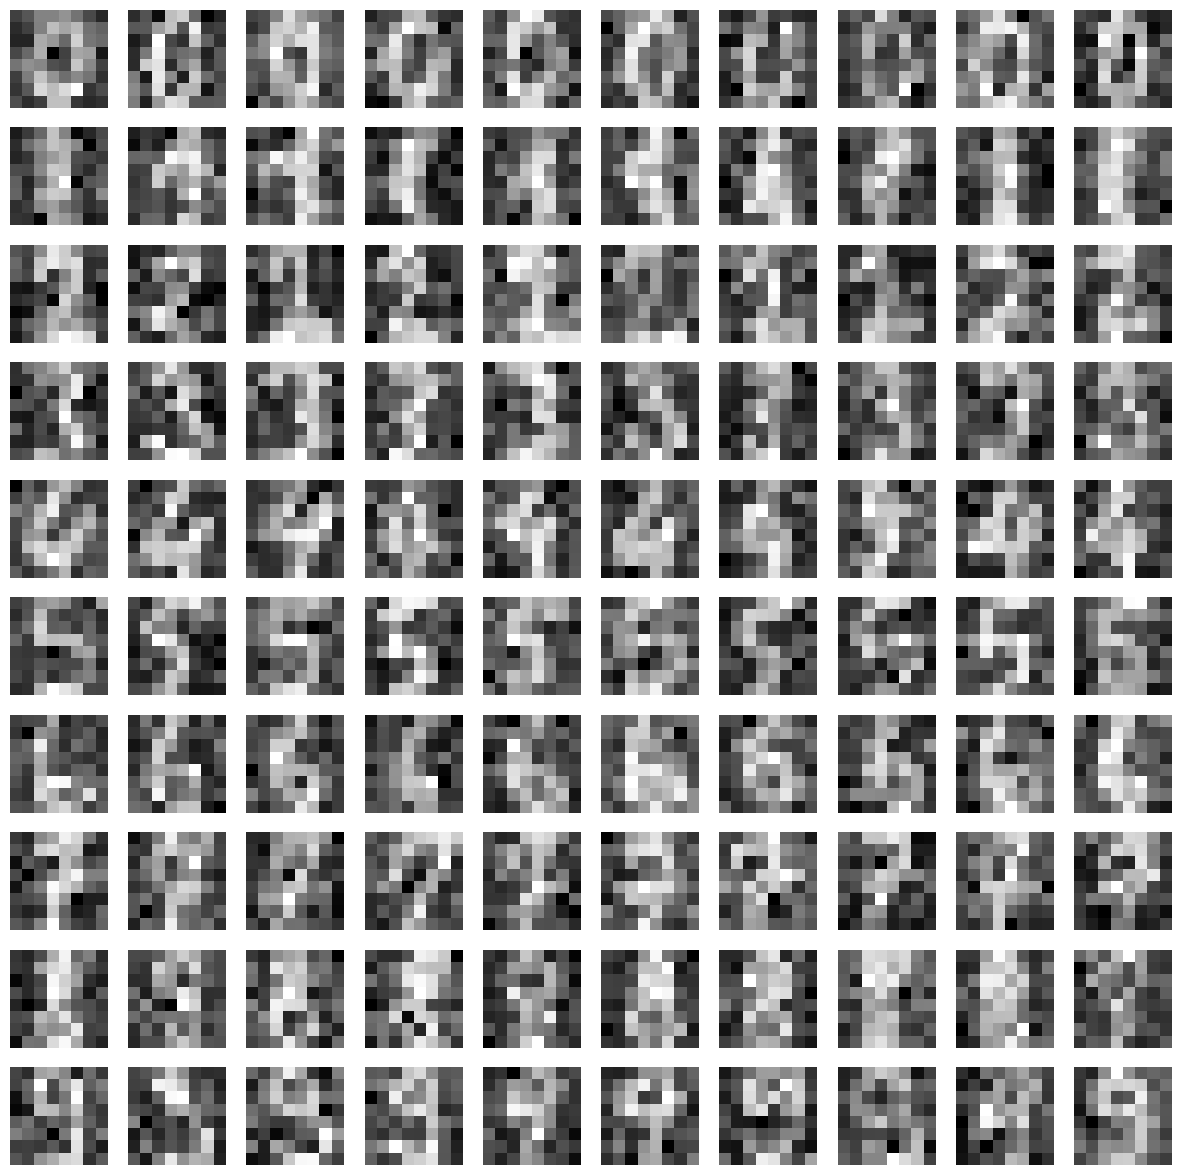

In [ ]:
np.random.seed(seed_value*3)
torch.manual_seed(seed_value*4)

def add_gaussian_noise(images, mean=0.0, std=1.0):
  noisy_images = images + np.random.normal(loc=mean, scale=std, size=images.shape)
  return noisy_images

X_train_noisy = add_gaussian_noise(X_train, mean=0.0, std=0.2)
X_val_noisy = add_gaussian_noise(X_val, mean=0.0, std=0.2)
X_test_noisy = add_gaussian_noise(X_test, mean=0.0, std=0.2)

fig, ax = plt.subplots(10, 10, figsize=(15, 15))

for digit_idx in range(10):
  occurance_idx_array = np.where(y_train == digit_idx)

  for j in range(10):
    ax[digit_idx, j].imshow(X_train_noisy[occurance_idx_array[0][j]], cmap='gray')
    ax[digit_idx, j].axis('off')

plt.show()

### Designing the denoising autoencoder

In [ ]:
class DenoisingAutoEncoder(nn.Module):
  def __init__(self, input_channels=1, out_channels=1, num_kernels=4):
    super().__init__()

    self.encode_conv_1_1 = nn.Conv2d(in_channels=input_channels, out_channels=num_kernels, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')
    self.encode_conv_1_2 = nn.Conv2d(in_channels=num_kernels, out_channels=num_kernels, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')

    self.encode_conv_2_1 = nn.Conv2d(in_channels=num_kernels, out_channels=num_kernels*2, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')
    self.encode_conv_2_2 = nn.Conv2d(in_channels=num_kernels*2, out_channels=num_kernels*2, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')

    self.encode_conv_3_1 = nn.Conv2d(in_channels=num_kernels*2, out_channels=num_kernels*4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')
    self.encode_conv_3_2 = nn.Conv2d(in_channels=num_kernels*4, out_channels=num_kernels*4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')

    self.bottleneck_conv_1 = nn.Conv2d(in_channels=num_kernels*4, out_channels=num_kernels*8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')
    self.bottleneck_conv_2 = nn.Conv2d(in_channels=num_kernels*8, out_channels=num_kernels*8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')

    self.decode_transpose_conv_1 = nn.ConvTranspose2d(in_channels=num_kernels*8, out_channels=num_kernels*4, kernel_size=(2, 2), stride=(2, 2))
    self.decode_conv_1_1 = nn.Conv2d(in_channels=num_kernels*4, out_channels=num_kernels*4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')
    self.decode_conv_1_2 = nn.Conv2d(in_channels=num_kernels*4, out_channels=num_kernels*4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')

    self.decode_transpose_conv_2 = nn.ConvTranspose2d(in_channels=num_kernels*4, out_channels=num_kernels*2, kernel_size=(2, 2), stride=(2, 2))
    self.decode_conv_2_1 = nn.Conv2d(in_channels=num_kernels*2, out_channels=num_kernels*2, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')
    self.decode_conv_2_2 = nn.Conv2d(in_channels=num_kernels*2, out_channels=num_kernels*2, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')

    self.decode_transpose_conv_3 = nn.ConvTranspose2d(in_channels=num_kernels*2, out_channels=num_kernels, kernel_size=(2, 2), stride=(2, 2))
    self.decode_conv_3_1 = nn.Conv2d(in_channels=num_kernels, out_channels=num_kernels, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')
    self.decode_conv_3_2 = nn.Conv2d(in_channels=num_kernels, out_channels=1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')

    self.relu = nn.ReLU()
    self.sigmoid = nn.Sigmoid()
    self.maxpool = nn.MaxPool2d((2, 2))

  def encode(self, input):
    output = self.relu(self.encode_conv_1_1(input))
    output = self.relu(self.encode_conv_1_2(output))
    output = self.maxpool(output)

    output = self.relu(self.encode_conv_2_1(output))
    output = self.relu(self.encode_conv_2_2(output))
    output = self.maxpool(output)

    output = self.relu(self.encode_conv_3_1(output))
    output = self.relu(self.encode_conv_3_2(output))
    output = self.maxpool(output)

    output = self.relu(self.bottleneck_conv_1(output))
    output = self.relu(self.bottleneck_conv_2(output))

    return output

  def decode(self, latent):
    output = self.relu(self.decode_transpose_conv_1(latent))
    output = self.relu(self.decode_conv_1_1(output))
    output = self.relu(self.decode_conv_1_2(output))

    output = self.relu(self.decode_transpose_conv_2(output))
    output = self.relu(self.decode_conv_2_1(output))
    output = self.relu(self.decode_conv_2_2(output))

    output = self.relu(self.decode_transpose_conv_3(output))
    output = self.relu(self.decode_conv_3_1(output))
    output = self.sigmoid(self.decode_conv_3_2(output))

    return output

  def forward(self, input):
    latent = self.encode(input)
    output = self.decode(latent)

    return output

ae_model = DenoisingAutoEncoder().to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
print("Autoencoder Model Summary:")
summary(ae_model, (1, 8, 8))

Autoencoder Model Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1              [-1, 4, 8, 8]              40
              ReLU-2              [-1, 4, 8, 8]               0
            Conv2d-3              [-1, 4, 8, 8]             148
              ReLU-4              [-1, 4, 8, 8]               0
         MaxPool2d-5              [-1, 4, 4, 4]               0
            Conv2d-6              [-1, 8, 4, 4]             296
              ReLU-7              [-1, 8, 4, 4]               0
            Conv2d-8              [-1, 8, 4, 4]             584
              ReLU-9              [-1, 8, 4, 4]               0
        MaxPool2d-10              [-1, 8, 2, 2]               0
           Conv2d-11             [-1, 16, 2, 2]           1,168
             ReLU-12             [-1, 16, 2, 2]               0
           Conv2d-13             [-1, 16, 2, 2]           2,320
            

### Defining hyperparameters, dataloaders and reconstruction loss

In [ ]:
np.random.seed(seed_value*5)
torch.manual_seed(seed_value*6)

batch_size = 2
learning_rate = 1.0e-3
num_epochs = 500

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_train_noisy_tensor = torch.tensor(X_train_noisy, dtype=torch.float32).unsqueeze(1)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)
X_val_noisy_tensor = torch.tensor(X_val_noisy, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
X_test_noisy_tensor = torch.tensor(X_test_noisy, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_noisy_tensor, X_train_tensor), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_noisy_tensor, X_val_tensor), batch_size=batch_size)
test_loader = DataLoader(TensorDataset(X_test_noisy_tensor, X_test_tensor), batch_size=batch_size)

criterion = nn.MSELoss()

In [ ]:
# Alternative reference: Sparse Autoencoder loss (MSE + KL sparsity penalty).
def sparse_autoencoder_loss(output, target, latent, rho=0.05, beta=1.0e-3):
  recon_loss = nn.MSELoss()(output, target)

  # Enforce average latent activation close to rho.
  rho_hat = torch.mean(torch.sigmoid(latent), dim=(0, 2, 3))
  eps = 1.0e-8
  rho_tensor = torch.full_like(rho_hat, rho)
  kl_sparsity = torch.sum(
      rho_tensor * torch.log((rho_tensor + eps) / (rho_hat + eps))
      + (1.0 - rho_tensor) * torch.log((1.0 - rho_tensor + eps) / (1.0 - rho_hat + eps))
  )

  total_loss = recon_loss + (beta * kl_sparsity)
  return total_loss, recon_loss, (beta * kl_sparsity)

# Example usage in training loop:
# latent = model.encode(noisy_imgs)
# outputs = model.decode(latent)
# loss, recon_loss, sparse_penalty = sparse_autoencoder_loss(outputs, clean_imgs, latent)

In [ ]:
# Alternative reference: Contractive Autoencoder loss (MSE + Jacobian penalty).
def contractive_autoencoder_loss(output, target, latent, encoder_weight, lam=1.0e-4):
  recon_loss = nn.MSELoss()(output, target)

  # ReLU derivative approximation for the latent activations.
  h_deriv = (latent > 0).float()
  frob_w = torch.sum(encoder_weight.view(encoder_weight.size(0), -1) ** 2)
  contractive_penalty = torch.sum(h_deriv ** 2) * frob_w

  total_loss = recon_loss + (lam * contractive_penalty)
  return total_loss, recon_loss, (lam * contractive_penalty)

# Example usage in training loop:
# latent = model.encode(noisy_imgs)
# outputs = model.decode(latent)
# loss, recon_loss, contractive_penalty = contractive_autoencoder_loss(
#     outputs, clean_imgs, latent, model.encode_conv_1_1.weight
# )

### Model initialization, optimizer definition, training and loss visualization

Epoch 1/500, Train Loss: 0.0869, Val Loss: 0.0750, Time: 4.1
Epoch 2/500, Train Loss: 0.0742, Val Loss: 0.0748, Time: 7.7
Epoch 3/500, Train Loss: 0.0735, Val Loss: 0.0750, Time: 12.3
Epoch 4/500, Train Loss: 0.0726, Val Loss: 0.0729, Time: 16.4
Epoch 5/500, Train Loss: 0.0720, Val Loss: 0.0724, Time: 20.1
Epoch 6/500, Train Loss: 0.0710, Val Loss: 0.0712, Time: 24.0
Epoch 7/500, Train Loss: 0.0699, Val Loss: 0.0700, Time: 28.2
Epoch 8/500, Train Loss: 0.0683, Val Loss: 0.0676, Time: 31.8
Epoch 9/500, Train Loss: 0.0666, Val Loss: 0.0660, Time: 35.4
Epoch 10/500, Train Loss: 0.0648, Val Loss: 0.0662, Time: 39.7
Epoch 11/500, Train Loss: 0.0635, Val Loss: 0.0640, Time: 43.4
Epoch 12/500, Train Loss: 0.0623, Val Loss: 0.0640, Time: 47.1
Epoch 13/500, Train Loss: 0.0618, Val Loss: 0.0618, Time: 51.4
Epoch 14/500, Train Loss: 0.0602, Val Loss: 0.0604, Time: 55.6
Epoch 15/500, Train Loss: 0.0596, Val Loss: 0.0617, Time: 59.2
Epoch 16/500, Train Loss: 0.0583, Val Loss: 0.0583, Time: 63.5
Epo

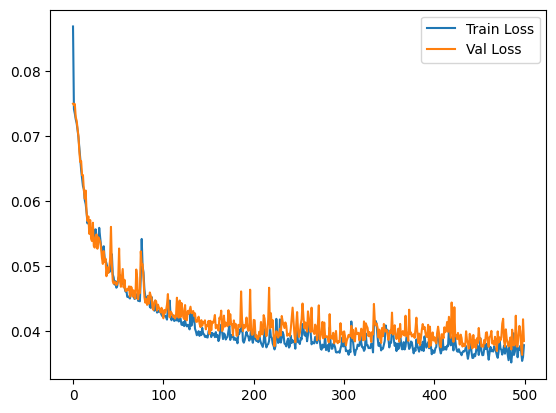

In [ ]:
np.random.seed(seed_value*7)
torch.manual_seed(seed_value*8)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenoisingAutoEncoder().to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

start_time = time.time()
train_losses, val_losses = [], []
for epoch in range(num_epochs):
  model.train()
  train_loss = 0
  for noisy_imgs, clean_imgs in train_loader:
    noisy_imgs, clean_imgs = noisy_imgs.to(device), clean_imgs.to(device)

    outputs = model(noisy_imgs)
    loss = criterion(outputs, clean_imgs)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss += loss.item()

  train_losses.append(train_loss / len(train_loader))

  model.eval()
  val_loss = 0
  with torch.no_grad():
    for noisy_imgs, clean_imgs in val_loader:
      noisy_imgs, clean_imgs = noisy_imgs.to(device), clean_imgs.to(device)
      outputs = model(noisy_imgs)
      loss = criterion(outputs, clean_imgs)
      val_loss += loss.item()

  val_losses.append(val_loss / len(val_loader))
  print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Time: {time.time() - start_time:.1f}")

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.show()

### Visualization of test outputs

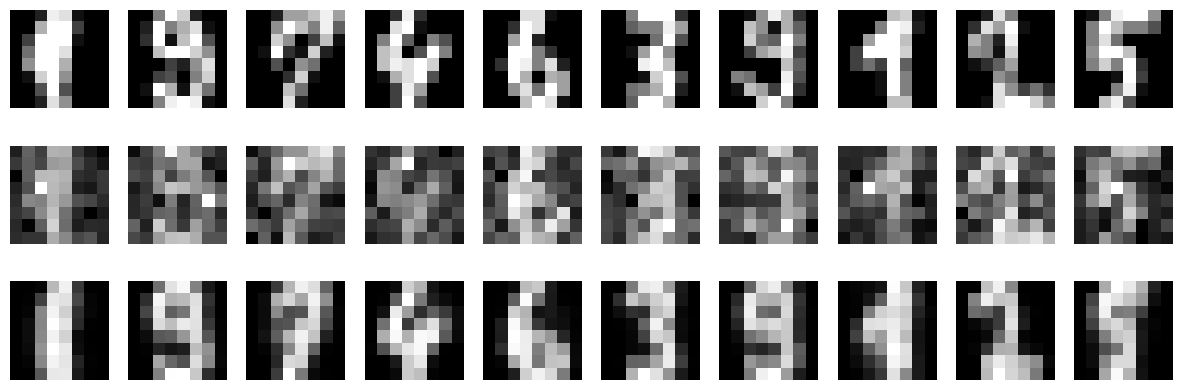

In [ ]:
model.eval()
denoised_imgs = []
with torch.no_grad():
  for noisy_imgs, _ in test_loader:
    noisy_imgs = noisy_imgs.to(device)
    outputs = model(noisy_imgs)
    denoised_imgs.append(outputs.cpu())

denosed_imgs = torch.cat(denoised_imgs).numpy()

fig, ax = plt.subplots(3, 10, figsize=(15, 5))

for i in range(10):
  ax[0, i].imshow(X_test[i].squeeze(), cmap='gray')
  ax[1, i].imshow(X_test_noisy[i].squeeze(), cmap='gray')
  ax[2, i].imshow(denosed_imgs[i].squeeze(), cmap='gray')

  for axes in ax[:, i]:
    axes.axis('off')

plt.show()

### Quantitative evaluation for denoising using autoencoder

In [ ]:
print(X_test.shape)
print(X_test_noisy.shape)
print(denosed_imgs.squeeze().shape)

mse_before = np.mean((X_test - X_test_noisy) ** 2)
mse_after = np.mean((X_test - denosed_imgs.squeeze()) ** 2)

print(f'MSE before denoising: {mse_before:.4f}')
print(f'MSE after denoising: {mse_after:.4f}')

(270, 8, 8)
(270, 8, 8)
(270, 8, 8)
MSE before denoising: 0.0399
MSE after denoising: 0.0411


# Variational Autoencoder (VAE)

### Loading Olivetti Faces dataset from Scikit-learn and visualization of some samples from the dataset

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Shape of dataset images: (400, 64, 64)
Shape of dataset labels: (400,)
Minimum pixel value of dataset images: 0.0
Maximum pixel value of dataset images: 1.0
Minimum label value of dataset images: 0
Maximum label value of dataset images: 39


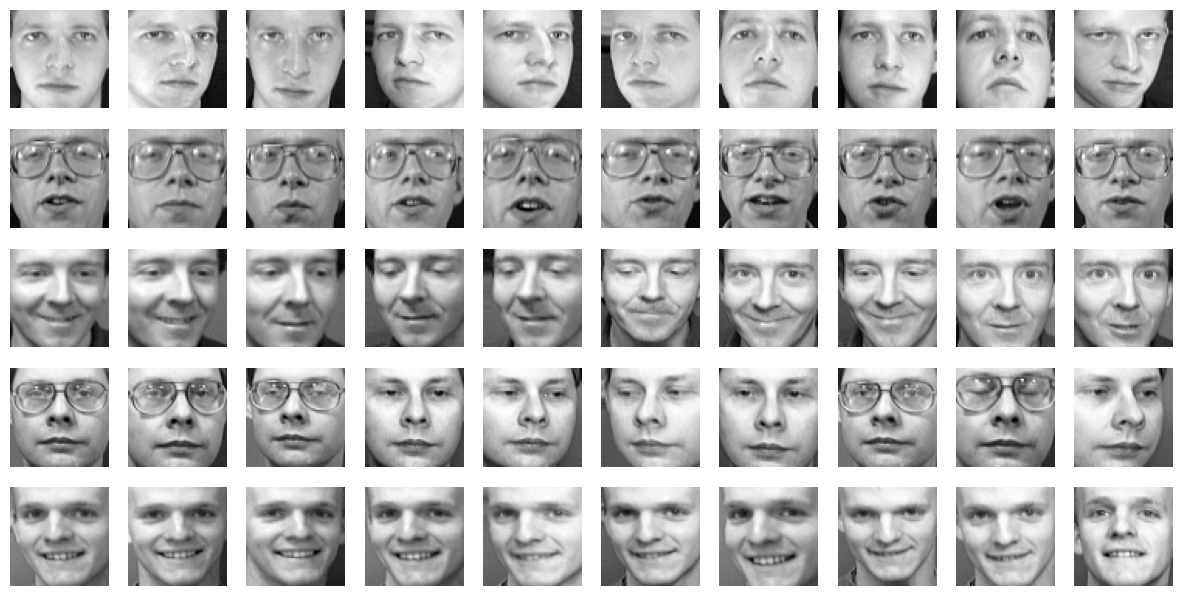

In [ ]:
faces = fetch_olivetti_faces()

X = faces.data.reshape(400, 64, 64)
y = faces.target

print("Shape of dataset images:", X.shape)
print("Shape of dataset labels:", y.shape)

print("Minimum pixel value of dataset images:", np.min(X))
print("Maximum pixel value of dataset images:", np.max(X))
print("Minimum label value of dataset images:", np.min(y))
print("Maximum label value of dataset images:", np.max(y))

fig, ax = plt.subplots(5, 10, figsize=(15, 7.5))

for digit_idx in range(5):
  occurance_idx_array = np.where(y == digit_idx)

  for j in range(10):
    ax[digit_idx, j].imshow(X[occurance_idx_array[0][j]], cmap='gray')
    ax[digit_idx, j].axis('off')

plt.show()

### Designing the VAE

In [ ]:
class VariationalAutoEncoder(nn.Module):
  def __init__(self, input_channels=1, out_channels=1, num_kernels=4):
    super().__init__()

    self.encode_conv_1_1 = nn.Conv2d(in_channels=input_channels, out_channels=num_kernels, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')
    self.encode_conv_1_2 = nn.Conv2d(in_channels=num_kernels, out_channels=num_kernels, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')

    self.encode_conv_2_1 = nn.Conv2d(in_channels=num_kernels, out_channels=num_kernels*2, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')
    self.encode_conv_2_2 = nn.Conv2d(in_channels=num_kernels*2, out_channels=num_kernels*2, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')

    self.encode_conv_3_1 = nn.Conv2d(in_channels=num_kernels*2, out_channels=num_kernels*4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')
    self.encode_conv_3_2 = nn.Conv2d(in_channels=num_kernels*4, out_channels=num_kernels*4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')

    self.bottleneck_conv_1 = nn.Conv2d(in_channels=num_kernels*4, out_channels=num_kernels*8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')
    self.bottleneck_conv_2_mu = nn.Conv2d(in_channels=num_kernels*8, out_channels=num_kernels*8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')
    self.bottleneck_conv_2_sigma = nn.Conv2d(in_channels=num_kernels*8, out_channels=num_kernels*8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')

    self.decode_transpose_conv_1 = nn.ConvTranspose2d(in_channels=num_kernels*8, out_channels=num_kernels*4, kernel_size=(2, 2), stride=(2, 2))
    self.decode_conv_1_1 = nn.Conv2d(in_channels=num_kernels*4, out_channels=num_kernels*4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')
    self.decode_conv_1_2 = nn.Conv2d(in_channels=num_kernels*4, out_channels=num_kernels*4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')

    self.decode_transpose_conv_2 = nn.ConvTranspose2d(in_channels=num_kernels*4, out_channels=num_kernels*2, kernel_size=(2, 2), stride=(2, 2))
    self.decode_conv_2_1 = nn.Conv2d(in_channels=num_kernels*2, out_channels=num_kernels*2, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')
    self.decode_conv_2_2 = nn.Conv2d(in_channels=num_kernels*2, out_channels=num_kernels*2, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')

    self.decode_transpose_conv_3 = nn.ConvTranspose2d(in_channels=num_kernels*2, out_channels=num_kernels, kernel_size=(2, 2), stride=(2, 2))
    self.decode_conv_3_1 = nn.Conv2d(in_channels=num_kernels, out_channels=num_kernels, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')
    self.decode_conv_3_2 = nn.Conv2d(in_channels=num_kernels, out_channels=1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode='replicate')

    self.relu = nn.ReLU()
    self.sigmoid = nn.Sigmoid()
    self.maxpool = nn.MaxPool2d((2, 2))

  def encode(self, input):
    output = self.relu(self.encode_conv_1_1(input))
    output = self.relu(self.encode_conv_1_2(output))
    output = self.maxpool(output)

    output = self.relu(self.encode_conv_2_1(output))
    output = self.relu(self.encode_conv_2_2(output))
    output = self.maxpool(output)

    output = self.relu(self.encode_conv_3_1(output))
    output = self.relu(self.encode_conv_3_2(output))
    output = self.maxpool(output)

    output = self.relu(self.bottleneck_conv_1(output))
    mu = self.bottleneck_conv_2_mu(output)
    log_var = self.bottleneck_conv_2_sigma(output)

    return mu, log_var

  def decode(self, latent):
    output = self.relu(self.decode_transpose_conv_1(latent))
    output = self.relu(self.decode_conv_1_1(output))
    output = self.relu(self.decode_conv_1_2(output))

    output = self.relu(self.decode_transpose_conv_2(output))
    output = self.relu(self.decode_conv_2_1(output))
    output = self.relu(self.decode_conv_2_2(output))

    output = self.relu(self.decode_transpose_conv_3(output))
    output = self.relu(self.decode_conv_3_1(output))
    output = self.sigmoid(self.decode_conv_3_2(output))

    return output

  def forward(self, input):
    mu, log_var = self.encode(input)
    std = torch.exp(0.5 * log_var)
    epsilon = torch.randn_like(std)
    latent = mu + (std * epsilon)
    output = self.decode(latent)

    return output, mu, log_var

vae_model = VariationalAutoEncoder().to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
print("Variational Autoencoder Model Summary:")
summary(vae_model, (1, 64, 64))

Variational Autoencoder Model Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 4, 64, 64]              40
              ReLU-2            [-1, 4, 64, 64]               0
            Conv2d-3            [-1, 4, 64, 64]             148
              ReLU-4            [-1, 4, 64, 64]               0
         MaxPool2d-5            [-1, 4, 32, 32]               0
            Conv2d-6            [-1, 8, 32, 32]             296
              ReLU-7            [-1, 8, 32, 32]               0
            Conv2d-8            [-1, 8, 32, 32]             584
              ReLU-9            [-1, 8, 32, 32]               0
        MaxPool2d-10            [-1, 8, 16, 16]               0
           Conv2d-11           [-1, 16, 16, 16]           1,168
             ReLU-12           [-1, 16, 16, 16]               0
           Conv2d-13           [-1, 16, 16, 16]           2,320


### Defining hyperparameters, dataloader and VAE loss (sum of reconstruction loss and KL-divergence loss)

In [ ]:
np.random.seed(seed_value*9)
torch.manual_seed(seed_value*10)

batch_size = 2
learning_rate = 1.0e-3
num_epochs = 500

X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=True)

def vae_loss(output, target, mu, log_var, beta=1.0):
  recon_criterion = nn.MSELoss()
  recon_loss = recon_criterion(output, target)
  kl_div_loss = torch.sum(0.5 * (log_var.exp() + mu.pow(2) - 1.0 - log_var))

  return recon_loss + (beta * kl_div_loss), recon_loss, (beta * kl_div_loss)

### Model initialization, optimizer definition and training

In [ ]:
np.random.seed(seed_value*11)
torch.manual_seed(seed_value*12)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VariationalAutoEncoder().to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

start_time = time.time()
train_losses = []
for epoch in range(num_epochs):
  model.train()
  train_loss = 0
  recon_loss_total = 0
  kl_div_loss_total = 0
  for clean_imgs, _ in train_loader:
    clean_imgs = clean_imgs.to(device)

    outputs, mu, log_var = model(clean_imgs)
    loss, recon_loss, kl_div_loss = vae_loss(outputs, clean_imgs, mu, log_var, beta=(1.0e-8 + ((epoch / num_epochs) * 1.0e-5)))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss += loss.item()
    recon_loss_total += recon_loss.item()
    kl_div_loss_total += kl_div_loss.item()

  train_losses.append(train_loss / len(train_loader))

  print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Recon loss: {(recon_loss_total/len(train_loader)):.4f}, KL-div loss: {(kl_div_loss_total/len(train_loader)):.4f}, Time: {time.time() - start_time:.1f}")

Epoch 1/500, Train Loss: 0.0301, Recon loss: 0.0301, KL-div loss: 0.0000, Time: 1.8
Epoch 2/500, Train Loss: 0.0201, Recon loss: 0.0200, KL-div loss: 0.0002, Time: 3.0
Epoch 3/500, Train Loss: 0.0092, Recon loss: 0.0090, KL-div loss: 0.0002, Time: 4.3
Epoch 4/500, Train Loss: 0.0077, Recon loss: 0.0074, KL-div loss: 0.0003, Time: 5.5
Epoch 5/500, Train Loss: 0.0074, Recon loss: 0.0070, KL-div loss: 0.0004, Time: 6.8
Epoch 6/500, Train Loss: 0.0071, Recon loss: 0.0066, KL-div loss: 0.0004, Time: 8.0
Epoch 7/500, Train Loss: 0.0067, Recon loss: 0.0063, KL-div loss: 0.0004, Time: 9.3
Epoch 8/500, Train Loss: 0.0064, Recon loss: 0.0060, KL-div loss: 0.0005, Time: 10.6
Epoch 9/500, Train Loss: 0.0063, Recon loss: 0.0058, KL-div loss: 0.0005, Time: 12.0
Epoch 10/500, Train Loss: 0.0060, Recon loss: 0.0056, KL-div loss: 0.0005, Time: 13.7
Epoch 11/500, Train Loss: 0.0059, Recon loss: 0.0054, KL-div loss: 0.0005, Time: 15.0
Epoch 12/500, Train Loss: 0.0055, Recon loss: 0.0050, KL-div loss: 0.0

### Construction of new face samples

In [ ]:
np.random.seed(seed_value*13)
torch.manual_seed(seed_value*14)

model.eval()
input_imgs, latent_tensors, output_imgs = [], [], []
input_label_idx = 0
with torch.no_grad():
  for input_label_idx in range(10):
    input_found_flag = False
    for input_samples, input_labels in train_loader:
      if not input_found_flag:
        if input_labels[0] == input_label_idx:
          input_found_flag = True

          input_imgs.append(input_samples[0].cpu())
          input_samples = input_samples.to(device)

          mu, log_var = model.encode(input_samples)
          std = torch.exp(0.5 * log_var)

          for multiple_output_idx in range(5):
            epsilon = torch.randn_like(std)
            latent = mu + (std * epsilon)
            output_samples = model.decode(latent)
            output_imgs.append(output_samples[0].cpu())

### Visualization of generated face samples

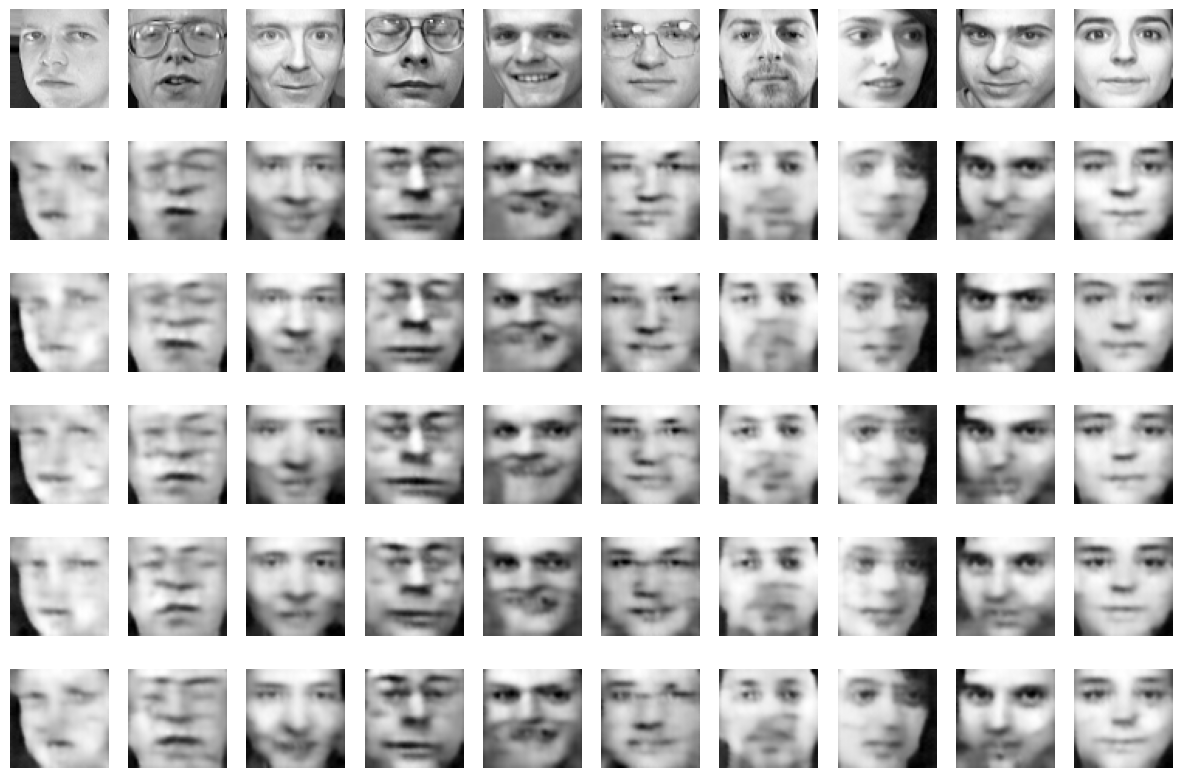

In [ ]:
fig, ax = plt.subplots(6, 10, figsize=(15, 10))

for i in range(10):
  ax[0, i].imshow(input_imgs[i].squeeze(), cmap='gray')
  for j in range(1, 6):
    ax[j, i].imshow(output_imgs[i*5 + (j-1)].squeeze(), cmap='gray')

  for axes in ax[:, i]:
    axes.axis('off')

plt.show()

#Assignment 09: Auto Encoders (AE) (20 marks)

## Instructions:

1. The content that you submit must be your individual work.
2. Submit your code in .py as well as in .ipynb file format. Both these file submissions are required to receive credit for this assignment.
3. Ensure your code is well-commented and easy to follow. You can write your answers and explanations using text cells in the jupyter notebook files wherever required.
4. The files should be named as “(roll_number)_assignment_9”. For example, if your roll number is 23AI91R01, the code file names will be 23AI91R01_assignment_9.py and 23AI91R01_assignment_9.ipynb. You should place all these files within a single .zip file (do not upload a .rar file) and upload it to Moodle as 23AI91R01_assignment_9.zip. The zip file should only contain the .py and .ipynb files, and nothing else.
5. All submissions must be made through Moodle before the deadline. The submission portal will close at the specified time, and submissions via email would not be accepted.
6. The .ipynb file acts as your assignment report in addition to the implementation. Therefore, ensure that the .ipynb file is clear and easy to assess. To discourage plagiarism, the .py file is used to check for plagiarism with very strict deduction criteria. Anyone trying to bypass the plagiarism check with means such as gibberish text inside the code will also experience harsh deduction.
7. The primary TA for assignment 1 is Raj Krishan Ghosh (rajkrishanghosh@kgpian.iitkgp.ac.in). In case you have any query regarding the assignment, you can email the TA. Please do not call.

## Question 0 (0 mark)

Load the flowers 102 dataset (train, val and test splits) from Torchvision: https://docs.pytorch.org/vision/main/generated/torchvision.datasets.Flowers102.html

## Question 1 (1 mark)

Resize the images to 64x64 and convert the RGB images into Lab colorspace using OpenCV.

## Question 2 (3 marks)

Create the dataloaders for the training, validation and test sets.Apply necessary augmentations (flip, rotations, crop and resize, color jitter etc) to the images from the training set to impart regularization

## Question 3 (7 marks)

Design an AE model using PyTorch to perform colorization on the grayscale images as follows:

* Encoder takes the L channel as input

* Decoder takes the latent representation derived from L and outputs the a and b channels

* The encoder and the decoder are constructed with convolutional blocks, similar to a UNet but without skip connections. For upsampling, transposed convolutional layers can be used. The model summary and parameter count needs to be shown, and needs to be between 1,000,000 and 2,500,000 trainable parameters.

## Question 4 (2 marks)

Design a suitable loss function for the colorization problem. The model can be trained using reconstruction loss (L1 loss or Mean Square Error loss) for a and b channels. Additionally, a histogram loss (to penalize difference in color distribution between prediction and ground truth) and a saturation loss (to penalize difference in saturation levels between prediction and ground truth) can also be used if required.

## Question 5 (3 marks)

Train the AE model and show the variation of the training and validation losses with training progress.

## Question 6 (1 mark)

Perform colorization on the test set using the trained VAE model and report the mean reconstruction error on the test set.

## Question 7 (3 marks)

Show some grayscale inputs, the corresponding ground truth color images and the colorized results produced by the trained AE.